In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/tarkwa_monthly_clean.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Set Date as index with explicit monthly frequency — SARIMA/pmdarima
# need this to correctly understand the 12-month seasonal cycle
series = df.set_index("Date")["Monthly_Rainfall_mm"]
series = series.asfreq("MS")  # MS = Month Start

print("Any gaps introduced by asfreq?", series.isna().sum())

# 80/20 chronological split — last ~20% becomes the test set
split_idx = int(len(series) * 0.8)
train, test = series.iloc[:split_idx], series.iloc[split_idx:]

print(f"\nTotal months: {len(series)}")
print(f"Train: {len(train)} months ({train.index.min().date()} to {train.index.max().date()})")
print(f"Test:  {len(test)} months ({test.index.min().date()} to {test.index.max().date()})")

Any gaps introduced by asfreq? 0

Total months: 285
Train: 228 months (1996-01-01 to 2014-12-01)
Test:  57 months (2015-01-01 to 2019-09-01)


In [2]:
import pmdarima as pm
import time

start = time.time()

auto_model = pm.auto_arima(
    train,
    seasonal=True,
    m=12,                  # confirmed seasonal period from our ACF analysis
    d=0,                   # ADF test confirmed stationarity already — no non-seasonal differencing needed
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    trace=True,             # prints every combination it tries — lets us see the search happen
    suppress_warnings=True,
    stepwise=True
)

elapsed = time.time() - start
print(f"\nSearch completed in {elapsed:.1f} seconds")
print("\nBest model summary:")
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=2657.897, Time=0.55 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=2765.533, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=2698.590, Time=0.28 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=2706.525, Time=0.24 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=3019.620, Time=0.01 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=2734.088, Time=0.11 sec
 ARIMA(0,0,0)(1,0,0)[12] intercept   : AIC=2715.098, Time=0.20 sec
 ARIMA(0,0,0)(2,0,1)[12] intercept   : AIC=2718.068, Time=1.30 sec
 ARIMA(0,0,0)(1,0,2)[12] intercept   : AIC=inf, Time=1.09 sec
 ARIMA(0,0,0)(0,0,2)[12] intercept   : AIC=2725.178, Time=0.32 sec
 ARIMA(0,0,0)(2,0,0)[12] intercept   : AIC=2692.271, Time=0.57 sec
 ARIMA(0,0,0)(2,0,2)[12] intercept   : AIC=inf, Time=1.42 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=2649.590, Time=0.53 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=2712.248, Time=0.24 sec
 ARIMA(1,0,0)(2,0,1)[12] inte

In [3]:
print("Chosen order (p,d,q):", auto_model.order)
print("Chosen seasonal order (P,D,Q,s):", auto_model.seasonal_order)
print("AIC of best model:", auto_model.aic())

Chosen order (p,d,q): (0, 0, 1)
Chosen seasonal order (P,D,Q,s): (1, 0, 1, 12)
AIC of best model: 2648.483846071345


In [4]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

n_test = len(test)
forecast, conf_int = auto_model.predict(n_periods=n_test, return_conf_int=True)

# Align forecast with test's actual dates
forecast = pd.Series(forecast, index=test.index)

rmse = np.sqrt(mean_squared_error(test, forecast))
mae = mean_absolute_error(test, forecast)
mape = np.mean(np.abs((test - forecast) / test)) * 100
r2 = r2_score(test, forecast)

print("SARIMA Test Set Performance:")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAE:  {mae:.2f}")
print(f"  MAPE: {mape:.2f}%")
print(f"  R²:   {r2:.4f}")

print("\nYour reference SARIMA metrics were: RMSE 74.76, MAE 56.71, MAPE 130.80%, R² 0.5545")

SARIMA Test Set Performance:
  RMSE: 81.15
  MAE:  62.79
  MAPE: 171.58%
  R²:   0.4750

Your reference SARIMA metrics were: RMSE 74.76, MAE 56.71, MAPE 130.80%, R² 0.5545


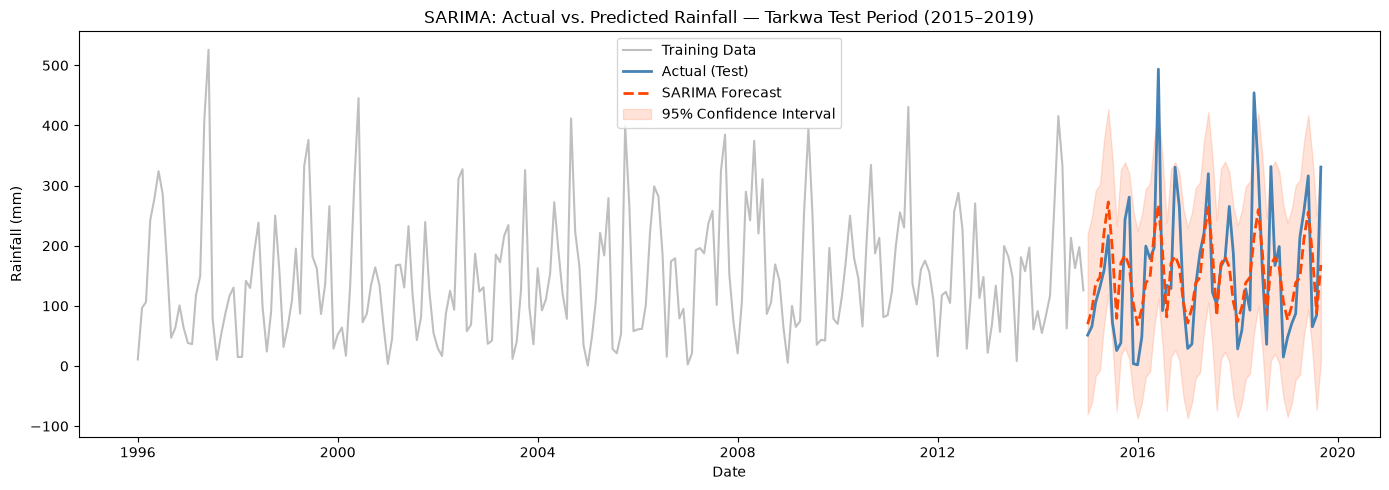

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(train.index, train, label="Training Data", color="gray", alpha=0.5)
plt.plot(test.index, test, label="Actual (Test)", color="steelblue", linewidth=2)
plt.plot(test.index, forecast, label="SARIMA Forecast", color="orangered", linewidth=2, linestyle="--")
plt.fill_between(test.index, conf_int[:, 0], conf_int[:, 1], color="orangered", alpha=0.15, label="95% Confidence Interval")

plt.title("SARIMA: Actual vs. Predicted Rainfall — Tarkwa Test Period (2015–2019)")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.tight_layout()
plt.savefig("../models/sarima_actual_vs_predicted.png", dpi=150)
plt.show()

In [7]:
import joblib

MODEL_PATH = "../models/sarima_model.pkl"
joblib.dump(auto_model, MODEL_PATH)

print(f"Model saved to {MODEL_PATH}")

# Quick reload check — confirms the saved file actually works, not just that it wrote to disk
loaded_model = joblib.load(MODEL_PATH)
test_forecast = loaded_model.predict(n_periods=3)
print("\nReload check — next 3 months forecast from loaded model:")
print(test_forecast)

Model saved to ../models/sarima_model.pkl

Reload check — next 3 months forecast from loaded model:
2015-01-01     69.530913
2015-02-01     93.300432
2015-03-01    137.531848
Freq: MS, dtype: float64
